In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_ind, ttest_1samp
from evaluations import *
import seaborn as sns 

In [2]:
mpl.rcParams['font.family'] = 'sans-serif' # Global font family
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}')

In [4]:
ROIs = ['PFC', 'visual', 'somatosensory', 'parietal'] 
n_rois = len(ROIs) 

## prediction error (cosine distances) computed using cross-validation 
On the training data (for each subject):

$V_{parcels \times conditions} = U_{parcels \times vertices} Y_{vertices \times conditions}$ 

Average V across subjects 

On the test data:

$\hat{Y} = U^{-1} V$ 

Compute the cosine distance between the actual test Y and $\hat{Y}$ 

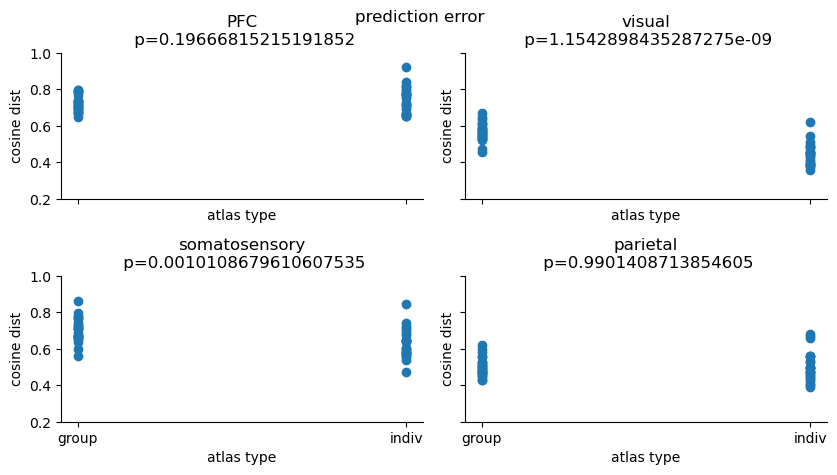

In [5]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)  
fig.set_figwidth(full_width) 

for roiI in np.arange(n_rois):
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
        
    cosine_distances_group = output_eval['cosine_distances_group']
    cosine_distances_indiv = output_eval['cosine_distances_indiv']

    x_group = np.ones(len(cosine_distances_group))
    x_indiv = 2*np.ones(len(cosine_distances_indiv))
    x_cosine_dist = np.concatenate([x_group, x_indiv])
    cosine_dist_concat = np.concatenate([cosine_distances_group, cosine_distances_indiv])
    ttest_result = ttest_ind(cosine_distances_group, cosine_distances_indiv, alternative='two-sided') 

    ax.ravel()[roiI].scatter(x_cosine_dist, cosine_dist_concat)
    ax.ravel()[roiI].set_xticks([1, 2], labels=['group', 'indiv'])
    ax.ravel()[roiI].set_xlabel('atlas type')
    ax.ravel()[roiI].set_ylabel('cosine dist')
    ax.ravel()[roiI].set_ylim([0.2, 1.0])
    ax.ravel()[roiI].set_title(f'{ROIs[roiI]}\n p={ttest_result.pvalue}') 
    ax.ravel()[roiI].spines['top'].set_visible(False)
    ax.ravel()[roiI].spines['right'].set_visible(False)

plt.tight_layout() 
plt.suptitle('prediction error') 

JPG_fig = os.path.join(resultsPath, f'prediction_error.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

## within- and between-parcel correlations

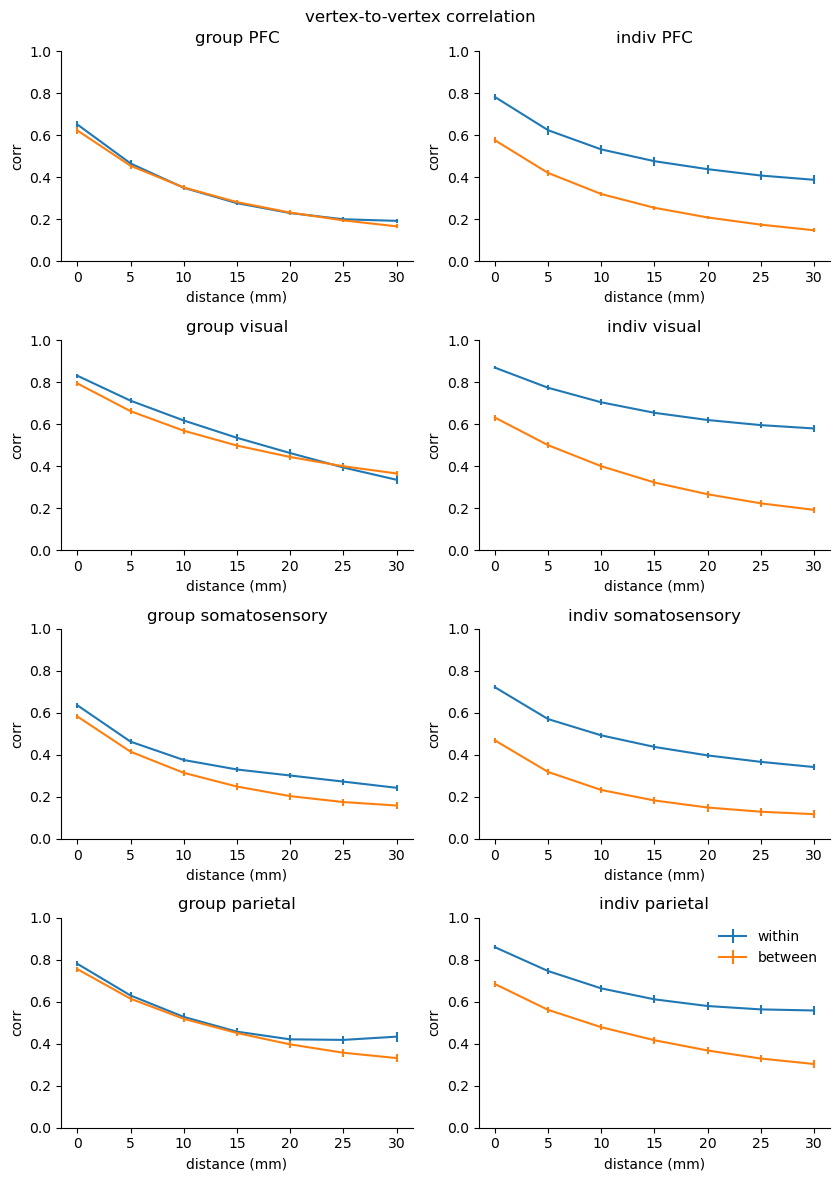

In [6]:
fig, ax = plt.subplots(n_rois, 2, figsize=(full_width, 12))

for roiI in np.arange(n_rois):
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
    output_dcbc_group = output_eval['output_dcbc_group']
    output_dcbc_indiv = output_eval['output_dcbc_indiv']

    # group 
    within_corrs = output_dcbc_group['within_corrs'] 
    between_corrs = output_dcbc_group['between_corrs']

    n_subjects = within_corrs.shape[0]

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    ax[roiI, 0].errorbar(np.arange(0, 35, step=5), within_corrs_mean, yerr=within_corrs_ste)
    ax[roiI, 0].errorbar(np.arange(0, 35, step=5), between_corrs_mean, yerr=between_corrs_ste)
    ax[roiI, 0].set_xlabel('distance (mm)')
    ax[roiI, 0].set_ylabel('corr')
    ax[roiI, 0].set_ylim([0, 1])
    ax[roiI, 0].spines['top'].set_visible(False)
    ax[roiI, 0].spines['right'].set_visible(False)
    plt.legend(['within', 'between'], frameon=False)
    ax[roiI, 0].set_title(f'group {ROIs[roiI]}') 

    # indiv
    within_corrs = output_dcbc_indiv['within_corrs'] 
    between_corrs = output_dcbc_indiv['between_corrs']

    within_corrs_mean = np.mean(within_corrs, axis=0)
    within_corrs_ste = np.std(within_corrs, axis=0) / np.sqrt(n_subjects)
    between_corrs_mean = np.mean(between_corrs, axis=0)
    between_corrs_ste = np.std(between_corrs, axis=0) / np.sqrt(n_subjects)

    ax[roiI, 1].errorbar(np.arange(0, 35, step=5), within_corrs_mean, yerr=within_corrs_ste)
    ax[roiI, 1].errorbar(np.arange(0, 35, step=5), between_corrs_mean, yerr=between_corrs_ste)
    ax[roiI, 1].set_xlabel('distance (mm)')
    ax[roiI, 1].set_ylabel('corr')
    ax[roiI, 1].set_ylim([0, 1])
    ax[roiI, 1].spines['top'].set_visible(False)
    ax[roiI, 1].spines['right'].set_visible(False)
    plt.legend(['within', 'between'], frameon=False)
    ax[roiI, 1].set_title(f'indiv {ROIs[roiI]}') 

plt.suptitle('vertex-to-vertex correlation') 
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'dcbc_corr_curves.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

## DCBC for group and individualized atlases 

t-test between group and indiv, PFC, p-val=2.0818339107591535e-17, t=-13.329199784391957, df=46.0
t-test against 0, group PFC, p-val=0.26105350504301184, t=0.6500396050979496, df=23
t-test against 0, indiv PFC, p-val=6.769186972206337e-13, t=13.77024093343398, df=23
t-test between group and indiv, visual, p-val=2.005793117694302e-21, t=-16.964592900504403, df=46.0
t-test against 0, group visual, p-val=0.15793519306369064, t=1.025331545028763, df=23
t-test against 0, indiv visual, p-val=3.3599784670697345e-17, t=21.886347091789098, df=23
t-test between group and indiv, somatosensory, p-val=1.86763274790658e-08, t=-6.792379928431508, df=46.0
t-test against 0, group somatosensory, p-val=2.10745290227197e-06, t=5.984057490747778, df=23
t-test against 0, indiv somatosensory, p-val=8.699288861609494e-12, t=12.144507845267368, df=23
t-test between group and indiv, parietal, p-val=1.2067335298098852e-16, t=-12.700534676954417, df=46.0
t-test against 0, group parietal, p-val=0.00684415409511048

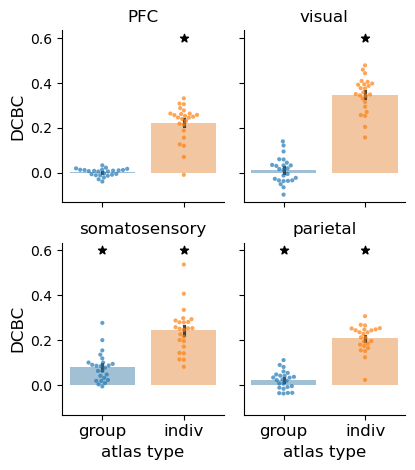

In [9]:
fig, axs = plt.subplots(2, 2, sharey=True, sharex=True) 
fig.set_figwidth(half_width)

for roiI in np.arange(n_rois):
    PKL_eval_output = os.path.join(resultsPath, f'output_{ROIs[roiI]}.pkl')
    with open(PKL_eval_output, 'rb') as pf:
        output_eval = pickle.load(pf) 
    output_dcbc_group = output_eval['output_dcbc_group']
    output_dcbc_indiv = output_eval['output_dcbc_indiv']

    dcbc_group = output_dcbc_group['dcbc']
    dcbc_indiv = output_dcbc_indiv['dcbc']
    
    sns.swarmplot([dcbc_group, dcbc_indiv], ax=axs.ravel()[roiI], size=3, alpha=0.7) 
    sns.barplot([dcbc_group, dcbc_indiv], errorbar='se', ax=axs.ravel()[roiI], alpha=0.45) 
    
    axs.ravel()[roiI].set_xticks([0, 1], labels=['group', 'indiv'], fontsize=12)
    axs.ravel()[roiI].set_xlabel('atlas type', fontsize=12)
    axs.ravel()[roiI].set_ylabel('DCBC', fontsize=12) 
    axs.ravel()[roiI].set_title(f'{ROIs[roiI]}') 
    axs.ravel()[roiI].spines['top'].set_visible(False)
    axs.ravel()[roiI].spines['right'].set_visible(False)
    
    ## some statistical tests
    significance_level = 0.05 

    ## t-test comparing group and individual 
    ttest_gi = ttest_ind(dcbc_group, dcbc_indiv, alternative='two-sided') 
    # if ttest_gi.pvalue < significance_level:
    #     axs.ravel()[roiI].hlines(0.5, xmin=1, xmax=2, linestyles='-', colors=(150/255, 150/255, 150/255)) 
    print(f't-test between group and indiv, {ROIs[roiI]}, p-val={ttest_gi.pvalue}, t={ttest_gi.statistic}, df={ttest_gi.df}')

    ## testing dcbc against 0 
    # group 
    ttest_0_g = ttest_1samp(dcbc_group, 0, alternative='greater')
    if ttest_0_g.pvalue < significance_level:
        axs.ravel()[roiI].scatter(0, 0.6, c='k', marker='*') 
    print(f't-test against 0, group {ROIs[roiI]}, p-val={ttest_0_g.pvalue}, t={ttest_0_g.statistic}, df={ttest_0_g.df}')
    # indiv
    ttest_0_i = ttest_1samp(dcbc_indiv, 0, alternative='greater')
    if ttest_0_i.pvalue < significance_level:
        axs.ravel()[roiI].scatter(1, 0.6, c='k', marker='*')
    print(f't-test against 0, indiv {ROIs[roiI]}, p-val={ttest_0_i.pvalue}, t={ttest_0_i.statistic}, df={ttest_0_i.df}')

plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'dcbc_group_indiv.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 